In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from unc_pma.environments import NoisyGridworld
from unc_pma.bayesian_qlearning import BayesianQLearning, NormalGamma
from unc_pma.environment_model import DirichletTransitionsModel
from unc_pma.replay_sampling_agent import ReplaySamplerAgent
from unc_pma.replay_buffer import Experience

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

Config : 'hard' -- 5x5, walls, slip=0.0, noise=0.3
states=25  actions=4  N_STEPS=50000  N_INIT_STEPS=400  WINDOW=200


<Axes: >

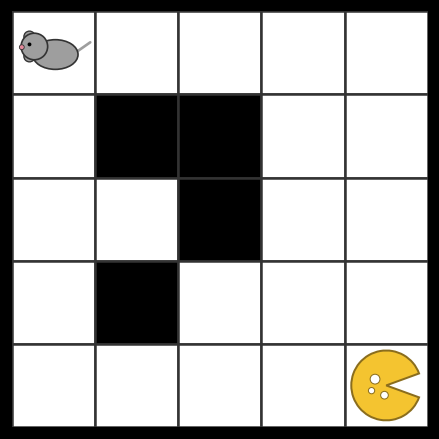

In [2]:
# Set WORLD = "easy"  ->  4x4, no walls, low noise
#     WORLD = "hard"  ->  5x5, walls,    higher noise
WORLD = "hard"

CONFIGS = {
    "easy": dict(
        height=4, width=4,
        start=(0, 0),
        goals={(3, 3): 1.0},
        walls=set(),
        slip_prob=0.0,#0.1,
        reward_noise=0.1,
        step_cost=0.01,
        gamma=0.99,
        n_steps=50_000,
        n_init_steps=4000,
        window=100,
        description="4x4, no walls, slip=0.0, noise=0.1",
    ),
    "hard": dict(
        height=5, width=5,
        start=(0, 0),
        goals={(4, 4): 1.0},
        walls={(1, 1), (1, 2), (2, 2), (3, 1)},
        slip_prob=0.1,#0.2,
        reward_noise=0.3,
        step_cost=0.01,
        gamma=0.99,
        n_steps=50000,
        n_init_steps=400,
        window=200,
        description="5x5, walls, slip=0.0, noise=0.3",
    ),
}

cfg          = CONFIGS[WORLD]
GAMMA        = cfg["gamma"]
N_STEPS      = cfg["n_steps"]
N_INIT_STEPS = cfg["n_init_steps"]
WINDOW       = cfg["window"]

env = NoisyGridworld(
    height      = cfg["height"],
    width       = cfg["width"],
    start       = cfg["start"],
    goals       = cfg["goals"],
    walls       = cfg["walls"],
    slip_prob   = cfg["slip_prob"],
    reward_noise= cfg["reward_noise"],
    step_cost   = cfg["step_cost"],
)
print(f"Config : {WORLD!r} -- {cfg['description']}")
print(f"states={env.n_states}  actions={env.n_actions}  "
      f"N_STEPS={N_STEPS}  N_INIT_STEPS={N_INIT_STEPS}  WINDOW={WINDOW}")
env.maze_render()

In [3]:
# --- Ground-truth transition model (Dirichlet) -----------------------------
# The agent isn't learning the maze dynamics from experience here: T(s'|s,a)
# is set directly to the environment's real deterministic transition (up/
# down/left/right; bumping into a wall or the boundary just keeps the agent
# in place -- env.deterministic_transition already encodes that). Unlike
# rewards, there's no genuine stochasticity in the maze's per-action
# dynamics to represent, so each (s, a) gets an *exact* one-hot posterior
# (alpha = 0 everywhere except the one true next state) rather than merely
# a heavily-concentrated one. A Dirichlet built by many .update() calls from
# a flat prior would still leave every other destination -- including
# non-adjacent cells, not just walls -- with a tiny nonzero residual
# probability, which is rare but real enough to occasionally get sampled
# and produce a "jump" over unvisited cells in a long replay trajectory.
transition_model = DirichletTransitionsModel(env.n_states, env.n_actions)
for r in range(env.height):
    for c in range(env.width):
        if (r, c) in env.walls:
            continue
        s = env._encode(r, c)
        for a in range(env.n_actions):
            next_state, _, _ = env.deterministic_transition(s, a)
            transition_model.alpha[s, a, :] = 0.0
            transition_model.alpha[s, a, next_state] = 1.0  # magnitude is irrelevant once every other entry is 0
# No real (s, a) ever lands on a wall with this seeding (deterministic_
# transition never returns one), so wall destinations are already exactly
# zero for every valid source row above -- nothing further needed there.

# Wall *source* rows are left unseeded above (the agent should never occupy
# one), so they still carry the class's flat alpha_prior across every
# destination. That's not just harmless dead weight: expected_prev_state_evb
# gathers a *column* of the transition tensor (T(s|s',a') for every
# candidate predecessor s'), which includes these wall rows. Their leftover
# flat prior gives them small-but-nonzero probability of "leading" to every
# real state, and that gets multiplied against compute_all_evb's -1e6
# invalid-state sentinel (since a wall row's own EVB is masked) -- injecting
# a large *negative* contamination into BEVB and making sample_replay never
# pick "backward". Give wall states a self-loop instead, so they carry zero
# probability toward every real state. This must run *last*: it sets
# alpha[wall, :, wall] = 1, so an earlier blanket "zero every wall
# destination column" pass would immediately erase it again.
wall_states = [env._encode(r, c) for (r, c) in env.walls]
transition_model.alpha[wall_states, :, :] = 0.0
for ws in wall_states:
    transition_model.alpha[ws, :, ws] = 1.0

# --- Ground-truth reward model (Bayesian Q-learning prior) -----------------
# Same idea for rewards, but rewards genuinely have noise (env.reward_noise),
# so unlike transitions this stays a *concentrated* posterior rather than an
# exact point mass. Each Q(s,a)'s Normal-Gamma prior is seeded with the
# environment's real one-step reward mean/noise for that (s,a) pair (its
# step_cost/goal reward and reward_noise), rather than starting from an
# uninformative prior and learning it via env.step(). lam/alpha match what
# `.update()` would produce after N_SEED_OBS real observations from a flat
# prior, so the posterior is confident about the mean -- matching "no need
# to learn."
N_SEED_OBS = 200  # "pretend we've already observed this reward N times"
LAM_SEED = 1.0 + N_SEED_OBS
ALPHA_SEED = 1.0 + N_SEED_OBS * 0.5
MIN_REWARD_STD = 1e-6  # numerical floor so NormalGamma.scale never hits exactly 0
WALL_PENALTY = -1.0    # well below any real reward (goal=+1.0, step_cost=-0.01)

q_model = BayesianQLearning(env.n_states, env.n_actions, gamma=GAMMA)
for r in range(env.height):
    for c in range(env.width):
        s = env._encode(r, c)
        if (r, c) in env.walls:
            # Walls are never a state the agent can occupy. Left at the
            # class's default flat prior (mu=0, low confidence), these
            # states carry *higher* VPI than the confidently-seeded real
            # ones -- uncertainty about an unvisited default reads as
            # "worth exploring" -- which is what made sample_tree_node's
            # EVB-softmax pick wall cells as replay roots. Seeding them as
            # confidently bad reduces that a lot, but VPI is E[max(.,0)]
            # >= 0 by construction, so it can never be pushed to exactly
            # zero this way -- see valid_states below for the actual fix.
            for a in range(env.n_actions):
                q_model._q[s][a] = NormalGamma(
                    mu=WALL_PENALTY, lam=LAM_SEED, alpha=ALPHA_SEED, beta=ALPHA_SEED * MIN_REWARD_STD ** 2,
                )
            continue
        for a in range(env.n_actions):
            _, base_reward, done = env.deterministic_transition(s, a)
            reward_std = env.reward_noise if (not env.reward_noise_at_goal_only or done) else 0.0
            reward_std = max(reward_std, MIN_REWARD_STD)
            q_model._q[s][a] = NormalGamma(
                mu=base_reward, lam=LAM_SEED, alpha=ALPHA_SEED, beta=ALPHA_SEED * reward_std ** 2,
            )

# --- Replay sampler ----------------------------------------------------------
# valid_states makes wall-exclusion exact rather than "very unlikely":
# compute_all_evb forces wall rows to a masking sentinel, so
# sample_tree_node's softmax gives them exactly zero probability of ever
# being chosen as a fresh root -- the only way (given the hard-zeroed
# wall-destination transitions above) a wall could become the search
# tree's current node at all.
valid_states = np.ones(env.n_states, dtype=bool)
valid_states[wall_states] = False

start_state = env._encode(*env.start)
replay_agent = ReplaySamplerAgent(
    q_model, transition_model,
    need_from_position=True,
    selection="evb",
    H=200,
    agent_real_state=start_state,
    SR_policy="greedy",
    valid_states=valid_states,
)

print(f"transition_model: n_states={transition_model.n_states} n_actions={transition_model.n_actions}")
print(f"q_model: n_states={q_model.n_states} n_actions={q_model.n_actions} gamma={q_model.gamma}")
print(f"replay_agent.agent_real_state={replay_agent.agent_real_state} (start={env.start})")
print(f"P(wall as destination) from valid sources, max: {transition_model.alpha[valid_states][:, :, wall_states].max()} (should be 0.0)")

transition_model: n_states=25 n_actions=4
q_model: n_states=25 n_actions=4 gamma=0.99
replay_agent.agent_real_state=0 (start=(0, 0))
P(wall as destination) from valid sources, max: 0.0 (should be 0.0)


Sampled 71 replay trajectories, lengths: [3, 2, 1, 3, 1, 3, 2, 2, 5, 1, 2, 2, 1, 1, 2, 2, 2, 3, 2, 1, 1, 1, 1, 2, 1, 3, 1, 3, 2, 1, 3, 1, 1, 2, 1, 3, 4, 1, 1, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 3, 1, 5, 2, 1, 1, 1, 2, 1, 1, 4, 1, 3, 2, 1, 2, 1, 1, 1, 4, 1, 1]


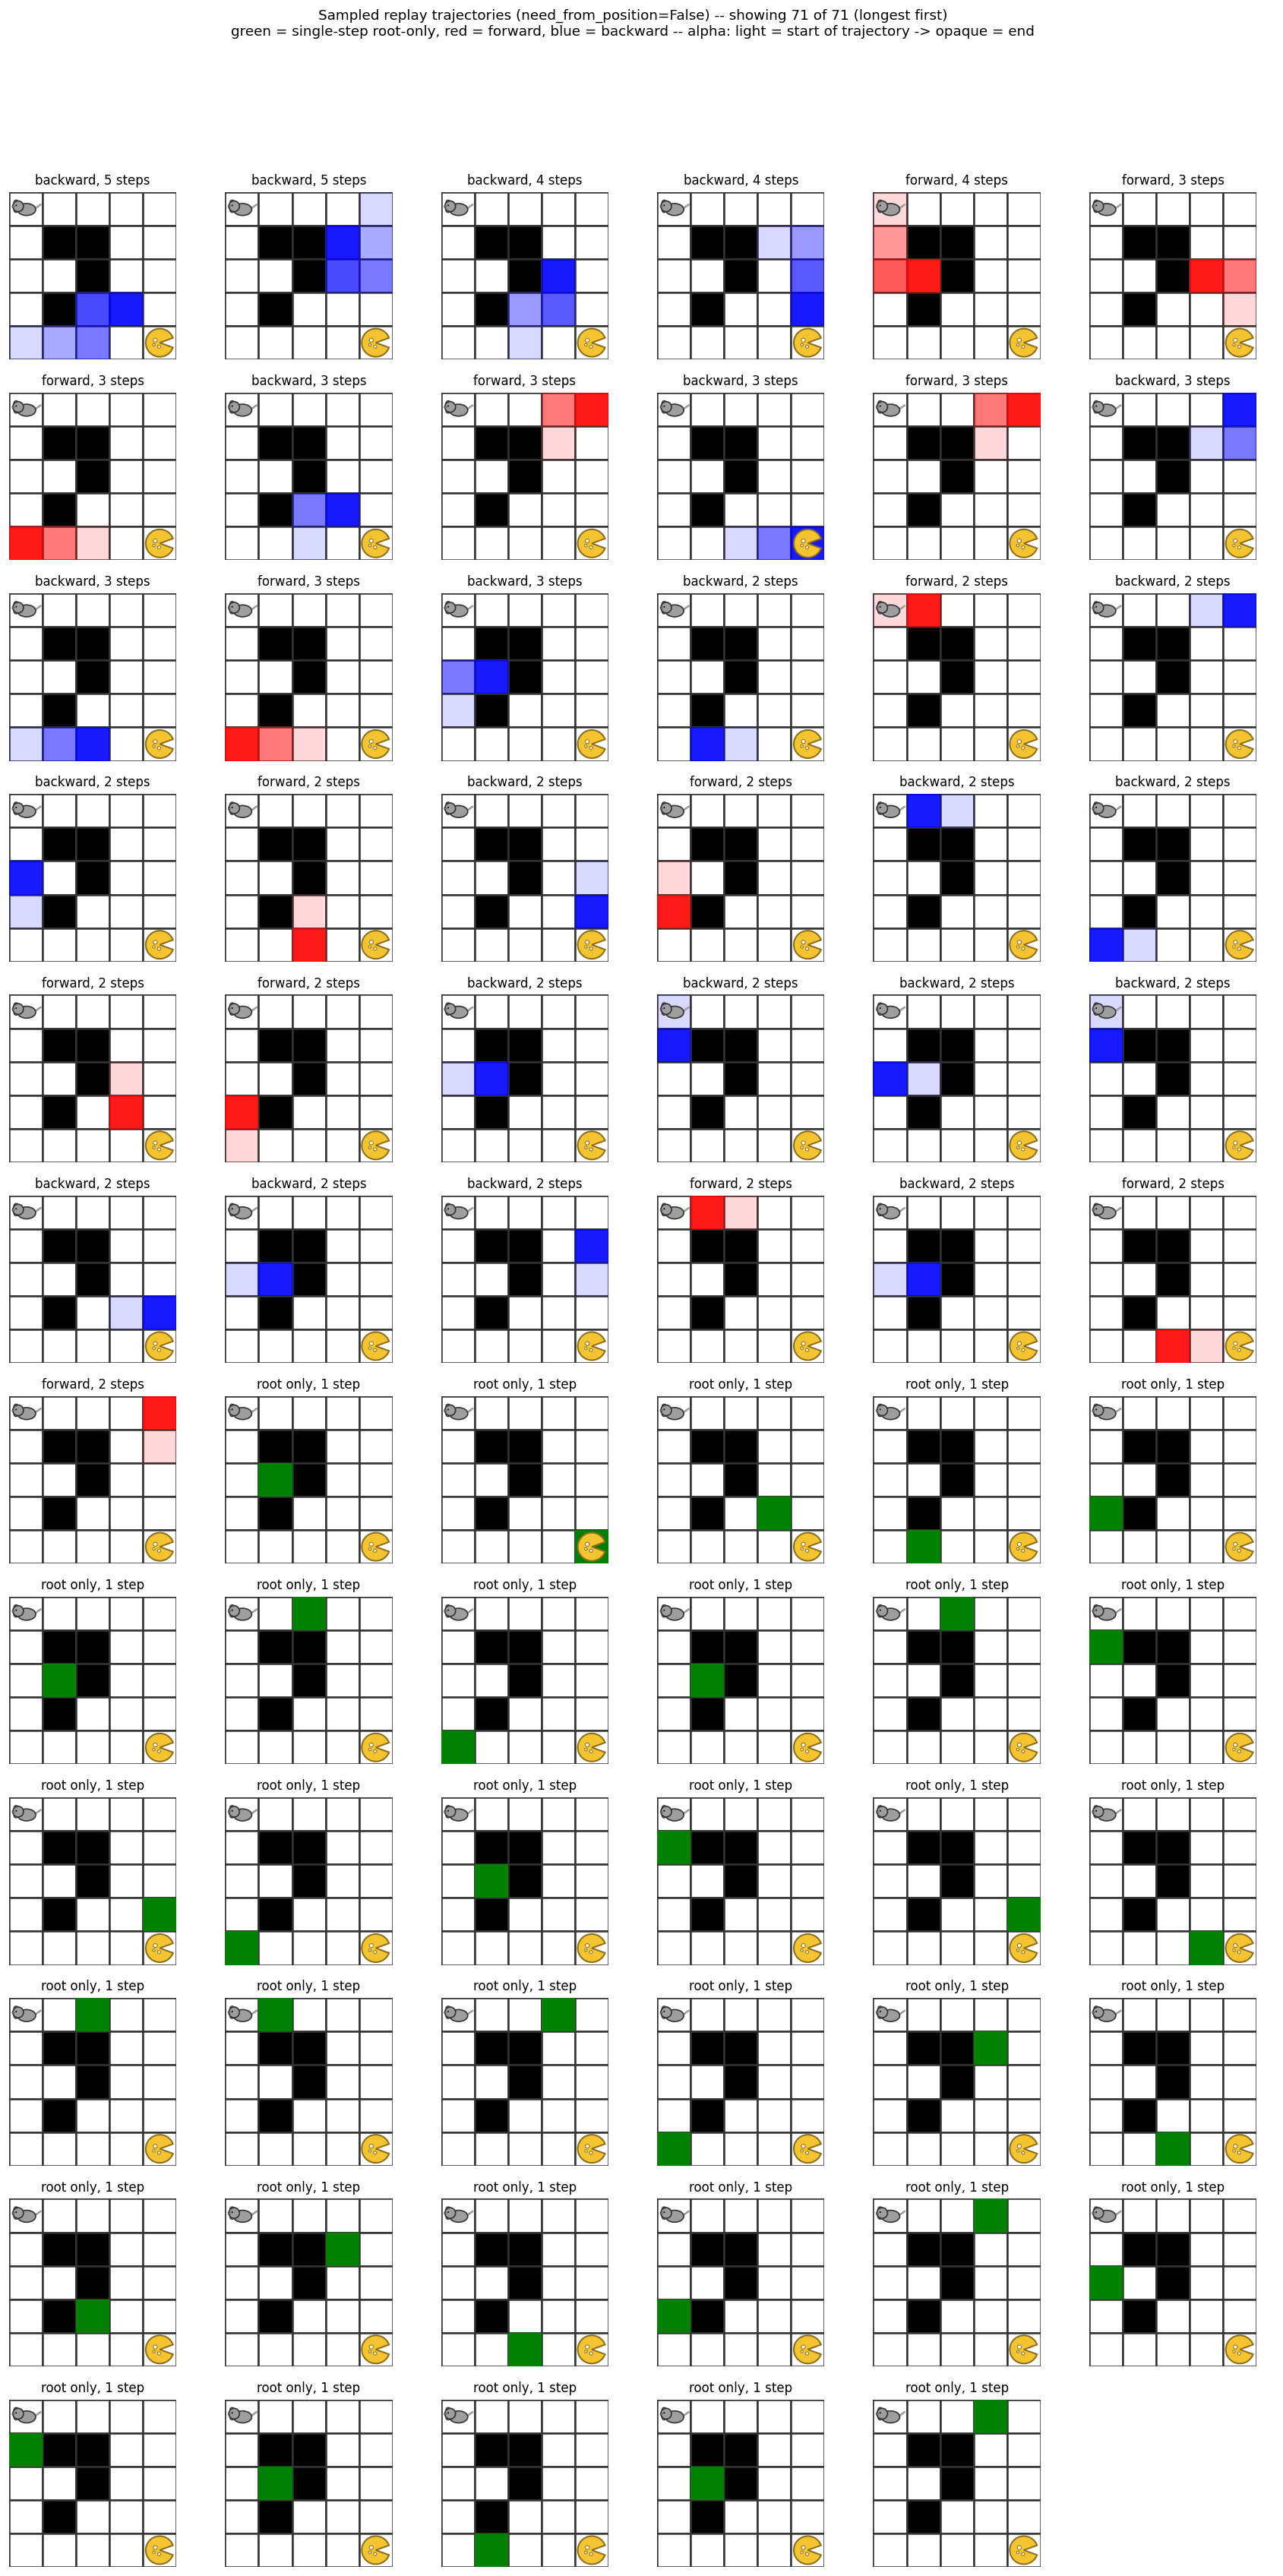

In [4]:
# --- Sample replay trajectories (need_from_position=False) -----------------
replay_agent.need_from_position = False
sequences, strategies = replay_agent.sample_replay(temp=1.0)
print(f"Sampled {len(sequences)} replay trajectories, lengths: {[len(t) for t in sequences]}")


def temporal_order(tree, strategy):
    """search_tree/tree_strategy are stored in *append* order, which only
    matches true chronological order for forward-growing (or root-only)
    trees. A backward-growing tree is built by repeatedly appending each
    newly-found predecessor to the end of the list (see sample_replay in
    replay_sampling_agent.py), so its append order is exactly reversed
    relative to when each state was actually visited. Forward and backward
    never mix within one un-flushed tree -- the strategy gating only lets
    you switch direction via a root reset, which starts a new tree -- so
    checking for "backward" anywhere in `strategy` is enough to know
    whether the whole tree needs reversing to read in chronological order.
    """
    if "backward" in strategy:
        return list(reversed(tree))
    return list(tree)


def plot_replay_tree(env, tree, strategy, ax):
    """Maze with this trajectory's visited states shaded green (single-step
    root-only), red (forward), or blue (backward), alpha increasing from
    the trajectory's true start (light) to its true end (opaque) -- using
    `strategy` to recover chronological order first.
    """
    ax.set_facecolor("white")
    env.maze_render(ax=ax)
    ordered = temporal_order(tree, strategy)
    n = len(ordered)
    direction = "backward" if "backward" in strategy else ("forward" if "forward" in strategy else "root only")
    color = "green" if direction == "root only" else ("blue" if direction == "backward" else "red")
    for i, sa in enumerate(ordered):
        r, c = env._decode(sa.state)
        alpha = 1.0 if n == 1 else 0.15 + 0.75 * (i / (n - 1))
        ax.add_patch(plt.Rectangle(
            (c - 0.5, -r - 0.5), 1, 1,
            facecolor=color, alpha=alpha, edgecolor="none", zorder=2,
        ))
    ax.set_title(f"{direction}, {n} step{'s' if n != 1 else ''}", fontsize=10, color="black")
    return ax


# H=200 can produce many short trees (most bouts flush back to "root"
# quickly) -- capping how many get plotted keeps the figure a reasonable
# size instead of a very tall, hard-to-scan grid. Longer trees are more
# informative than length-1 ones, so show the longest ones first.
MAX_TREES_TO_PLOT = 72
order = sorted(range(len(sequences)), key=lambda i: -len(sequences[i]))[:MAX_TREES_TO_PLOT]

n_trees = len(order)
ncols = min(n_trees, 6)
nrows = -(-n_trees // ncols)  # ceil
# facecolor="white" (figure and every axes) plus explicit color="black" on
# all text below override whatever theme the notebook environment injects
# (e.g. a Jupyter/IDE dark-mode setting). Without both, the figure can come
# out either an opaque black background swallowing the plot, or a correct
# white background with titles rendered white-on-white and invisible --
# either way it looks like "nothing was generated" at a glance even though
# every subplot's content is actually correct.
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.4), facecolor="white")
axes = np.atleast_1d(axes).ravel()

for ax, i in zip(axes, order):
    plot_replay_tree(env, sequences[i], strategies[i], ax)
for ax in axes[n_trees:]:
    ax.axis("off")

fig.suptitle(
    f"Sampled replay trajectories (need_from_position=False) -- "
    f"showing {n_trees} of {len(sequences)} (longest first)\n"
    "green = single-step root-only, red = forward, blue = backward -- alpha: light = start of trajectory -> opaque = end",
    fontsize=11, color="black",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()